# Guppy Multiple MA -- do twelve moving averages beat one?
### Daryl Guppy's twin-ribbon trend filter, tested honestly, in plain English

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Reveals_conviction%3F: Busted](https://img.shields.io/badge/Reveals_conviction%3F-Busted-8b949e?style=flat-square)

Daryl Guppy's GMMA is one of the most recognisable indicators in retail charting: two coloured *ribbons* of moving averages, a fast one (3-15 days) for traders and a slow one (30-60 days) for investors. The folklore says you ride the trend when the fast ribbon is above the slow one, and you *trust* the trend most when the two ribbons are wide apart -- that spacing is supposed to reveal **conviction**. This notebook asks the only question that matters: does any of it actually beat just holding the market?

> **This is the plain-language layer.** Want the HAC *t*-stats, the permutation placebo and the single-EMA benchmark? That's the companion, **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** -- same story, deeper.
>
> **Not investment advice.** A reproducible research tool: every chart below is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))           # the study package
sys.path.insert(0, os.path.abspath("../../.."))     # repo root
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False,
                     "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from guppy_mma import data, strategy as st

TICKER = "SPY"
RF     = 0.04 / 252.0   # flat 4%/yr cash proxy
COST   = 2.0            # one-way bps x NAV
SMA_N  = 50

# Frozen real-tape headline numbers -- mirror of docs/results.md (as-of 2026-06-13).
R = dict(
    n=8400, start="1993-01-29", end="2026-06-12", fp="42b159a9d39a",
    in_mkt=71.7, n_switches=259,
    bh_cagr=6.47, bh_sharpe=0.431, bh_vol=18.6, bh_dd=-64.0, bh_t=2.89,
    rb_cagr=2.80, rb_sharpe=0.301, rb_vol=11.3, rb_dd=-47.5, rb_t=1.86,
    cv_cagr=1.42, cv_sharpe=0.210, cv_dd=-38.0, cv_t=1.30,
    sma_cagr=1.77, sma_sharpe=0.215, sma_t=1.31,
    ema_cagr=3.16, ema_sharpe=0.337, ema_t=2.09,
    rn_cagr=3.36, rn_sharpe=0.288, rn_dd=-60.7, rn_t=1.81,
    t_rb_vs_bh=-2.10, t_rb_vs_rand=-0.50, t_rb_vs_sma=1.26, t_cv_vs_rb=-1.30,
    perm_p=0.969, perm_real_bps=2.55, perm_mean_bps=3.39,
    sweep_0=0.315, sweep_2=0.301, sweep_5=0.280, sweep_10=0.246,
    syn_edge_rb_sh=0.264, syn_edge_bh_sh=-0.149, syn_edge_t_vs_bh=2.35, syn_edge_perm_p=0.0135,
    syn_null_rb_sh=0.306, syn_null_bh_sh=0.323, syn_null_t_vs_bh=-0.85, syn_null_perm_p=0.2674,
)

def _have_cache():
    return os.path.exists(data._cache_path(TICKER, data.DEFAULT_CACHE))

HAVE_REAL = _have_cache()
print("real SPY cache present:", HAVE_REAL)

if HAVE_REAL:
    df    = data.load_real(TICKER, fetch=False)
    close = df["close"]
    res   = st.run_experiment(close, rf_daily=RF, cost_bps=COST, sma_n=SMA_N, allow_short=False)
    s_bh  = res["bh"]; s_rb = res["ribbon"]; s_cv = res["conviction"]
    s_sma = res["sma"]; s_ema = res["ema"]; s_rn = res["random"]
    in_mkt = res["in_market_frac"]
else:
    close = None
    mk = lambda c, sh, dd: dict(cagr=c/100, sharpe=sh, max_drawdown=dd/100)
    s_bh  = mk(R["bh_cagr"], R["bh_sharpe"], R["bh_dd"])
    s_rb  = mk(R["rb_cagr"], R["rb_sharpe"], R["rb_dd"])
    s_cv  = mk(R["cv_cagr"], R["cv_sharpe"], R["cv_dd"])
    s_sma = mk(R["sma_cagr"], R["sma_sharpe"], -54.7)
    s_ema = mk(R["ema_cagr"], R["ema_sharpe"], -42.7)
    s_rn  = mk(R["rn_cagr"], R["rn_sharpe"], R["rn_dd"])
    in_mkt = R["in_mkt"] / 100
    res = None


real SPY cache present: True


## The answer first

| Question | Answer |
|---|---|
| Does the ribbon beat buy-and-hold? | **No.** Excess Sharpe **+0.301** vs buy-and-hold **+0.431** -- and the gap is statistically *against* the ribbon (*t* = -2.10). |
| Is it better than one moving average? | **No.** A single 50-day EMA earns a *higher* Sharpe (+0.337) than the twelve-line ribbon (+0.301). |
| Does it beat a coin-flip schedule? | **No.** A random in/out schedule with the same in-market fraction matches it (*t* = -0.50). A rotation placebo beats the real signal **97%** of the time. |
| Does 'wide ribbon = conviction' help? | **It hurts.** Gating on ribbon width *lowers* the Sharpe (+0.210). Width is hindsight, not a forecast. |

> The GMMA's only real effect is being out of the market ~28% of the time, which lowers both risk and return. It is a single trend filter wearing a costume of twelve lines.

## 1 -- The claim

> *'The GMMA uses two groups of moving averages. The short-term group (3, 5, 8, 10, 12, 15) shows what traders are doing. The long-term group (30, 35, 40, 45, 50, 60) shows what investors are doing. When the short group is above the long group, the trend is up. When the two groups are well separated and moving in parallel, the trend has conviction and will continue. When they compress, the trend is ending.'*
> -- the Daryl Guppy / GMMA folklore

It is a genuinely appealing story: it claims to read not just *direction* (like any moving average) but *agreement* between two kinds of market participant. If the spacing between the ribbons really forecasts whether a trend continues, that would be information a single moving average cannot give you.

## 2 -- So what?

If the ribbon's conviction reading worked, it would be a free upgrade for millions of retail traders who already have GMMA on their charts -- a way to filter out the weak trends that whipsaw a plain moving-average rule. And it would be a small but real dent in the efficient-market view: it would mean the *shape* of a fan of moving averages predicts returns beyond what the price level already tells you.

Conversely, if the ribbon is just a slow-vs-fast crossover with extra decoration, then the honest comparison is brutal: it must beat (a) holding the market, (b) one moving average, and (c) flipping a coin to decide when to be in. Those are the three bars.

## 3 -- How would we even know?

Four tests keep us honest:

1. **The buy-and-hold race.** Does the ribbon's risk-adjusted return beat just owning SPY? We compare *excess-of-cash* Sharpe to *excess-of-cash* Sharpe (a fair race, since the rule sits in cash part-time).
2. **The single-moving-average benchmark.** Does the twelve-line ribbon beat **one** 50-day moving average? If not, the extra eleven lines are decoration.
3. **The random-timing control.** A coin that goes to cash as often as the ribbon, but on random days. If the ribbon doesn't beat it, the 'timing' is just reduced exposure.
4. **The conviction test.** Gate the long leg on the ribbon being *wider than usual*. If Guppy is right, that should *improve* results. We'll see it does the opposite.

## 4 -- The teardown -- let's actually look

**First, the ribbons themselves on a slice of SPY, so you can see the indicator.**

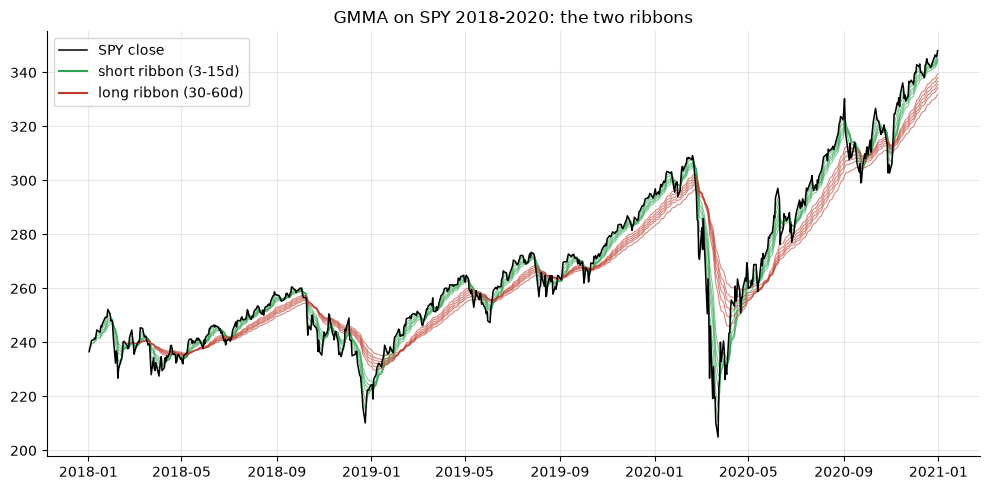

In [2]:
if HAVE_REAL:
    sl = close.loc['2018-01-01':'2020-12-31']
    rb = st.ribbons(sl)
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(sl.index, sl, c='k', lw=1.1, label='SPY close', zorder=5)
    for c_ in rb['short'].columns:
        ax.plot(sl.index, rb['short'][c_], c=GREEN, lw=0.8, alpha=0.6)
    for c_ in rb['long'].columns:
        ax.plot(sl.index, rb['long'][c_], c=RED, lw=0.8, alpha=0.6)
    ax.plot([], [], c=GREEN, label='short ribbon (3-15d)')
    ax.plot([], [], c=RED, label='long ribbon (30-60d)')
    ax.set_title('GMMA on SPY 2018-2020: the two ribbons'); ax.legend()
else:
    fig, ax = plt.subplots(); ax.text(0.5,0.5,'cache not available',ha='center')
plt.tight_layout(); plt.show()


You can *see* the 2020 COVID crash compress and flip the ribbons -- that is the indicator doing exactly what it is supposed to. The question is whether acting on it pays. **Now the scorecard: risk-adjusted return of every arm.**

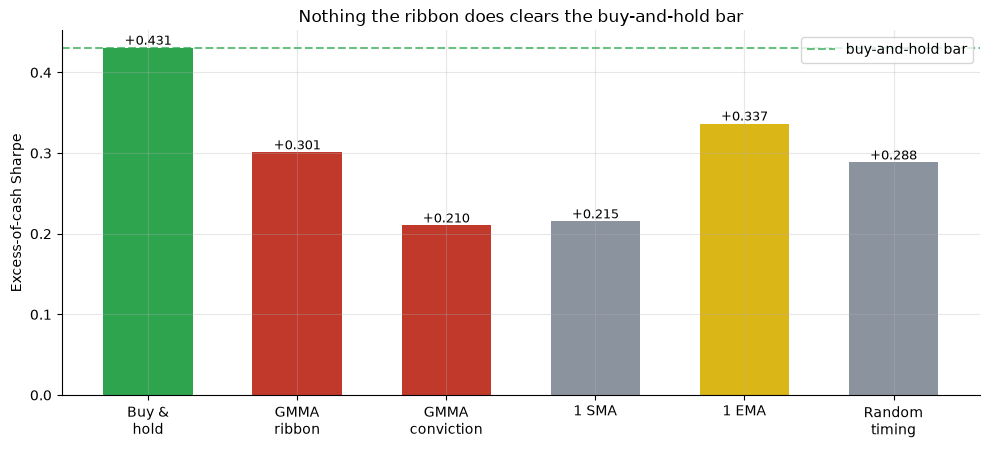

ribbon +0.301 < buy-and-hold +0.431; one EMA +0.337 even beats the ribbon


In [3]:
labels = ['Buy &\nhold', 'GMMA\nribbon', 'GMMA\nconviction', '1 SMA', '1 EMA', 'Random\ntiming']
sharpes = [s_bh['sharpe'], s_rb['sharpe'], s_cv['sharpe'], s_sma['sharpe'], s_ema['sharpe'], s_rn['sharpe']]
colors  = [GREEN, RED, RED, GREY, AMBER, GREY]
fig, ax = plt.subplots(figsize=(10, 4.6))
bars = ax.bar(labels, sharpes, color=colors, width=0.6)
for b, v in zip(bars, sharpes):
    ax.annotate(f'{v:+.3f}', (b.get_x()+b.get_width()/2, v), ha='center',
                va='bottom', fontsize=9)
ax.axhline(s_bh['sharpe'], ls='--', c=GREEN, alpha=0.7, label='buy-and-hold bar')
ax.set_ylabel('Excess-of-cash Sharpe'); ax.legend()
ax.set_title('Nothing the ribbon does clears the buy-and-hold bar')
plt.tight_layout(); plt.show()
print(f'ribbon {s_rb["sharpe"]:+.3f} < buy-and-hold {s_bh["sharpe"]:+.3f}; one EMA {s_ema["sharpe"]:+.3f} even beats the ribbon')


The green dashed line is buy-and-hold (+0.431). Every GMMA bar sits *below* it. Worse, the single 50-day EMA (+0.337) edges out the twelve-line ribbon (+0.301), and the 'conviction' gate is the *lowest* bar of all (+0.210). The ribbon's apparatus buys nothing.

## 5 -- The verdict

- **Signal -- NONE.** Excess Sharpe +0.301, beaten by buy-and-hold (*t* = -2.10), tied by a coin-flip schedule, and a rotation placebo beats the real signal 97% of the time.
- **Tradability -- MIRAGE.** Even before any costs the ribbon's Sharpe (+0.315) trails buy-and-hold. There is no edge to scale.
- **Reveals conviction? -- BUSTED.** Gating on ribbon width makes everything worse. Width describes a trend that already happened; it does not forecast the next one.

## 6 -- Could you actually trade it?

There is nothing here to trade -- but it is worth seeing *why* the lower risk is a trap, not a feature. The ribbon's drawdown is lower than buy-and-hold's, which looks nice. But a random schedule that sits in cash just as often gets a similar risk cut for free -- the reduction is exposure, not skill.

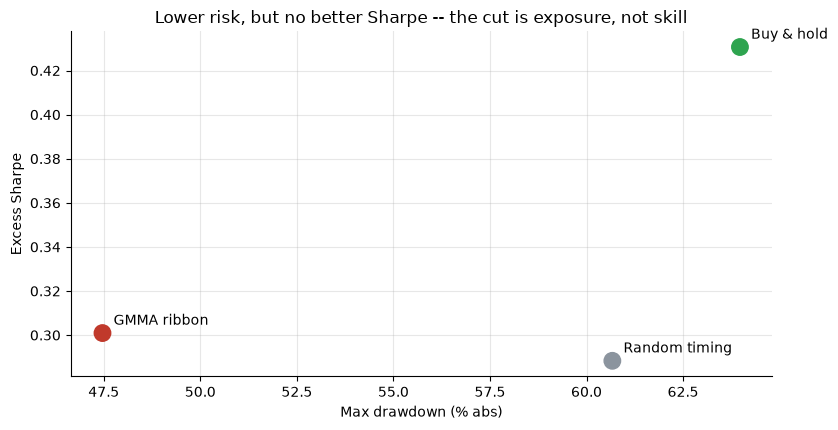

In [4]:
fig, ax = plt.subplots(figsize=(8.5, 4.4))
arms = ['Buy & hold', 'GMMA ribbon', 'Random timing']
dds  = [abs(s_bh['max_drawdown'])*100, abs(s_rb['max_drawdown'])*100, abs(s_rn['max_drawdown'])*100]
shs  = [s_bh['sharpe'], s_rb['sharpe'], s_rn['sharpe']]
ax.scatter(dds, shs, s=[140,140,140], c=[GREEN, RED, GREY], zorder=3)
for a, d, s in zip(arms, dds, shs):
    ax.annotate(a, (d, s), textcoords='offset points', xytext=(8, 6))
ax.set_xlabel('Max drawdown (% abs)'); ax.set_ylabel('Excess Sharpe')
ax.set_title('Lower risk, but no better Sharpe -- the cut is exposure, not skill')
plt.tight_layout(); plt.show()


The ribbon (red) does have a smaller drawdown than buy-and-hold (green), but its Sharpe is *lower*, and a random schedule (grey) lands in the same neighbourhood. You would be giving up 3.7 points of annual return to buy a risk cut you could get by flipping a coin. That is not a strategy.

## 7 -- Going further

- **Other instruments.** We tested SPY. The ribbon might behave differently on a trendier asset (a commodity, a single momentum stock). Fork `data.load_real` with another ticker and re-run -- the engine is generic.
- **Long/short.** We ran long/flat. The quants notebook shows the long/short version is *sharply negative* -- shorting on a ribbon down-cross fights the market's drift.
- **A real trend rule that works.** [Study 110 (Faber-Timing)](../../110-faber-timing/) shows a single-SMA rule that *does* earn a real risk stamp. The contrast is the lesson: the GMMA's twelve lines add complexity, not edge.

*Think the ribbon shines somewhere SPY hides it? Fork this, point it at a trending market, and show the excess-vs-excess Sharpe clearing the bar. That's the standard.*